In [1]:
pwd

'/gpfs/data/arsoyd01lab/machlm03/Segmentation/MedSAM2/oai_utils'

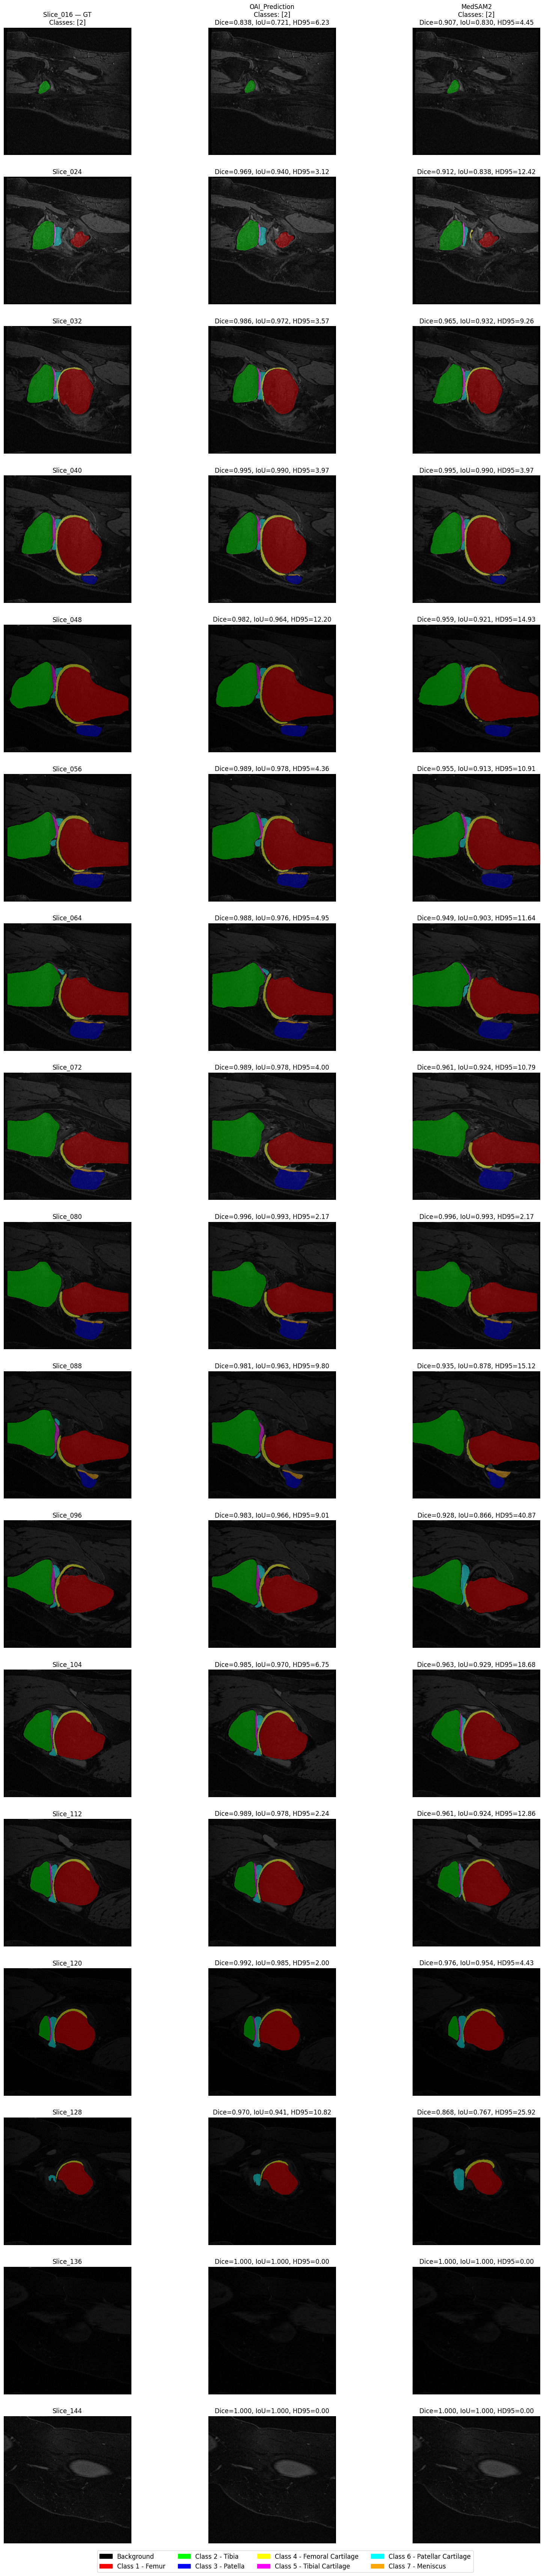


=== EVALUATION RESULTS ===
Evaluated classes: [1, 2, 3, 4, 5, 6, 7]
Mean Dice over selected frames: 0.978
Mean IoU over selected frames:  0.960
Mean HD95 OAI over selected frames: 5.01
Mean HD95 MedSAM over selected frames: 11.67

Per-frame results:
Frame 016: Dice=0.838, IoU=0.721, HD95_OAI=6.23, HD95_Medsam=4.45
Frame 024: Dice=0.969, IoU=0.940, HD95_OAI=3.12, HD95_Medsam=12.42
Frame 032: Dice=0.986, IoU=0.972, HD95_OAI=3.57, HD95_Medsam=9.26
Frame 040: Dice=0.995, IoU=0.990, HD95_OAI=3.97, HD95_Medsam=3.97
Frame 048: Dice=0.982, IoU=0.964, HD95_OAI=12.20, HD95_Medsam=14.93
Frame 056: Dice=0.989, IoU=0.978, HD95_OAI=4.36, HD95_Medsam=10.91
Frame 064: Dice=0.988, IoU=0.976, HD95_OAI=4.95, HD95_Medsam=11.64
Frame 072: Dice=0.989, IoU=0.978, HD95_OAI=4.00, HD95_Medsam=10.79
Frame 080: Dice=0.996, IoU=0.993, HD95_OAI=2.17, HD95_Medsam=2.17
Frame 088: Dice=0.981, IoU=0.963, HD95_OAI=9.80, HD95_Medsam=15.12
Frame 096: Dice=0.983, IoU=0.966, HD95_OAI=9.01, HD95_Medsam=40.87
Frame 104: Dice

In [1]:
import numpy as np
from PIL import Image, ImageOps
from pathlib import Path
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from scipy.spatial.distance import directed_hausdorff

# Explicit mapping from grayscale to class-ID
GRAY_TO_CLASS = {
    0: 0,    # background
    60: 1,   # class 1
    120: 2,  # class 2
    180: 3,  # class 3
    240: 4,  # class 4
    44: 5,   # class 5
    164: 6,  # class 6
    104: 7,  # class 7
}

# Define class colors for visualization
CLASS_COLORS = {
    0: (0, 0, 0),           # background - black
    1: (255, 0, 0),         # red
    2: (0, 255, 0),         # green
    3: (0, 0, 255),         # blue
    4: (255, 255, 0),       # yellow
    5: (255, 0, 255),       # magenta
    6: (0, 255, 255),       # cyan
    7: (255, 165, 0),       # bright orange (instead of gray)
}

# Legend mapping for class names and colors
CLASS_NAMES = {
    0: "Background",
    1: "Class 1 - Femur",
    2: "Class 2 - Tibia",
    3: "Class 3 - Patella",
    4: "Class 4 - Femoral Cartilage",
    5: "Class 5 - Tibial Cartilage",
    6: "Class 6 - Patellar Cartilage",
    7: "Class 7 - Meniscus",
}

def hd95(gt_mask, pred_mask):
    gt_points = np.argwhere(gt_mask)
    pred_points = np.argwhere(pred_mask)
    if gt_points.size == 0 or pred_points.size == 0:  # Fixed: == instead of missing ==
        return 0.0  # or np.nan if you want to skip empty masks
    forward_hd = directed_hausdorff(gt_points, pred_points)[0]
    backward_hd = directed_hausdorff(pred_points, gt_points)[0]
    return np.percentile([forward_hd, backward_hd], 95)

def remap_with_lookup(mask_img):
    arr = np.array(mask_img, dtype=np.int16)
    lut = np.zeros(256, dtype=np.uint8)
    for gray, cls in GRAY_TO_CLASS.items():
        lut[gray] = cls
    return lut[arr]

def mask_ids_to_rgb(mask_ids, class_colors):
    h, w = mask_ids.shape
    rgb = np.zeros((h, w, 3), dtype=np.uint8)
    for cls, color in class_colors.items():
        rgb[mask_ids == cls] = color
    return Image.fromarray(rgb)

def dice_iou(gt_bool, pred_bool):
    """Calculate Dice and IoU scores for boolean masks"""
    intersection = np.logical_and(gt_bool, pred_bool).sum()
    union = np.logical_or(gt_bool, pred_bool).sum()
    gt_sum = gt_bool.sum()
    pred_sum = pred_bool.sum()
    # Handle edge cases
    if gt_sum == 0 and pred_sum == 0:  # Fixed: == instead of missing ==
        return 1.0, 1.0  # Perfect match when both are empty
    if union == 0:
        return 0.0, 0.0  # No union means no overlap
    dice = 2 * intersection / (gt_sum + pred_sum) if (gt_sum + pred_sum) > 0 else 0.0
    iou = intersection / union if union > 0 else 0.0
    return dice, iou

def list_images(directory):
    """List image files in directory"""
    extensions = ['.png', '.jpg', '.jpeg']
    files = []
    for ext in extensions:
        files.extend(directory.glob(f'*{ext}'))
        files.extend(directory.glob(f'*{ext.upper()}'))
    return [str(f) for f in files]

def overlay_image_mask(img_path, mask_path, class_colors, alpha=0.4):
    """Overlay a single mask (GT or prediction) on the original image."""
    img = Image.open(img_path).convert("RGB")
    img = ImageOps.exif_transpose(img)
    mask = Image.open(mask_path).convert("L")
    mask_rgb = mask_ids_to_rgb(remap_with_lookup(mask), class_colors)  # Fixed: added remap_with_lookup
    if mask_rgb.size != img.size:
        mask_rgb = mask_rgb.resize(img.size, Image.NEAREST)
    return Image.blend(img, mask_rgb, alpha=alpha)

# Case definition
case = "9256759_00m_LEFT_SAG_3D_DESS_WE"

# Path definitions
input_path = f"/gpfs/home/machlm03/Segmentation/OAI_demo/OAI_TrainTest/V00_00m_test_1.0/{case}"
pre_masks_dir_oai = f"/gpfs/home/machlm03/Segmentation/OAI_demo/MedSAM_Finetune_OAI_Inference/fold5/{case}"
pre_masks_dir_medsam2 = f"/gpfs/home/machlm03/Segmentation/OAI_demo/MedSam2_OAI_Inference/{case}"

mask_path = Path(f"{input_path}/masks")       # GT masks
img_path = Path(f"{input_path}/imgs_png")     # Original images
pre_masks_dir_oai = Path(f"{pre_masks_dir_oai}/imgs")        # Predicted masks
pre_masks_dir_medsam2 = Path(f"{pre_masks_dir_medsam2}/imgs")  # medsam2 prediction

# Evaluate all classes present in your data
labels = [1, 2, 3, 4, 5, 6, 7]  # All classes except background

# --- Match frames ---
frame_files = list_images(mask_path)
mask_files = list_images(pre_masks_dir_oai)
sam_mask_files = list_images(pre_masks_dir_medsam2)

frame_map = {Path(f).stem: f for f in frame_files}
mask_map = {Path(f).stem: f for f in mask_files}
sam_mask_map = {Path(f).stem: f for f in sam_mask_files}

# Check for common files
common = sorted(set(frame_map) & set(mask_map))
if not common:
    raise RuntimeError("No matching frame/mask filenames (by stem).")

common = sorted(set(frame_map) & set(sam_mask_map))
if not common:
    raise RuntimeError("No matching frame/mask filenames (by sam_mask_map).")

# Select 3 key frames
num_frames = len(common)
# sel_raw = [0.35, 0.45, 0.65, 0.75, 0.85]
sel_raw = [.1,.15,.20,0.25, 0.30,.35,.40,.45, 0.50,.55,.6,.65,.70, 0.75,.80,.85,.90]

selected_indices = [min(num_frames - 1, max(0, int(num_frames * r))) for r in sel_raw]
selected_keys = [common[i] for i in selected_indices]

# --- Main loop ---
dice_scores = []
iou_scores = []
hd_scores_oai = []
hd_scores_msam = []

plt.figure(figsize=(18, len(selected_keys) * 4))  # 3 columns

for row_idx, k in enumerate(selected_keys):
    img_file = img_path / f"{k}.png"         # Original image
    gt_file = mask_path / frame_map[k]       # GT mask
    pred_file = pre_masks_dir_oai / mask_map[k]   # Fixed: use pre_masks_dir_oai
    
    # Load GT and prediction masks
    gt_mask_img = Image.open(gt_file).convert("L")
    pred_mask_img = Image.open(pred_file).convert("L")
    
    # Remap to class IDs
    gt_ids = remap_with_lookup(gt_mask_img)
    pred_ids = remap_with_lookup(pred_mask_img)
    
    # Show which classes from your labels are actually present
    gt_labels_present = [l for l in labels if l in gt_ids]
    pred_labels_present = [l for l in labels if l in pred_ids]
    
    # Boolean masks for selected labels
    gt_bool = np.isin(gt_ids, labels)
    pred_bool = np.isin(pred_ids, labels)
    
    # MedSAM predictions
    sam_pred_file = pre_masks_dir_medsam2 / sam_mask_map[k]   # Fixed: use pre_masks_dir_medsam2
    sam_mask_img = Image.open(sam_pred_file).convert("L")
    sam_ids = remap_with_lookup(sam_mask_img)
    sam_labels_present = [l for l in labels if l in sam_ids]
    sam_bool = np.isin(sam_ids, labels)
    
    # Compute metrics
    d, j = dice_iou(gt_bool, pred_bool)
    d_sam, j_sam = dice_iou(gt_bool, sam_bool)
    hd = hd95(gt_bool, pred_bool)
    hd_sam = hd95(gt_bool, sam_bool)
    
    dice_scores.append(d)
    iou_scores.append(j)
    hd_scores_oai.append(hd)
    hd_scores_msam.append(hd_sam)
    
    # Create overlays
    if img_file.exists():
        base_img = Image.open(img_file).convert("RGB")
        base_img = ImageOps.exif_transpose(base_img)
        
        # Resize masks to match image size if needed
        gt_rgb = mask_ids_to_rgb(gt_ids, CLASS_COLORS)
        pred_rgb = mask_ids_to_rgb(pred_ids, CLASS_COLORS)
        sam_rgb = mask_ids_to_rgb(sam_ids, CLASS_COLORS)
        
        if gt_rgb.size != base_img.size:
            gt_rgb = gt_rgb.resize(base_img.size, Image.NEAREST)
        if pred_rgb.size != base_img.size:
            pred_rgb = pred_rgb.resize(base_img.size, Image.NEAREST)
        if sam_rgb.size != base_img.size:
            sam_rgb = sam_rgb.resize(base_img.size, Image.NEAREST)
            
        gt_overlay = Image.blend(base_img, gt_rgb, alpha=0.4)
        pred_overlay = Image.blend(base_img, pred_rgb, alpha=0.4)
        sam_overlay = Image.blend(base_img, sam_rgb, alpha=0.4)
    else:
        # If no base image, just show the masks
        gt_overlay = mask_ids_to_rgb(gt_ids, CLASS_COLORS)
        pred_overlay = mask_ids_to_rgb(pred_ids, CLASS_COLORS)
        sam_overlay = mask_ids_to_rgb(sam_ids, CLASS_COLORS)
    
    # GT overlay
    plt.subplot(len(selected_keys), 3, row_idx * 3 + 1)
    plt.imshow(gt_overlay)
    if row_idx == 0:
        plt.title(f"Slice_{k} — GT\nClasses: {gt_labels_present}")
    else:
        plt.title(f"Slice_{k}")
    plt.axis("off")
    
    # Your prediction overlay
    plt.subplot(len(selected_keys), 3, row_idx * 3 + 2)
    plt.imshow(pred_overlay)
    if row_idx == 0:
        plt.title(f"OAI_Prediction\nClasses: {pred_labels_present}\nDice={d:.3f}, IoU={j:.3f}, HD95={hd:.2f}")
    else:
        plt.title(f"\nDice={d:.3f}, IoU={j:.3f}, HD95={hd:.2f}")
    plt.axis("off")
    
    # MedSAM2 overlay
    plt.subplot(len(selected_keys), 3, row_idx * 3 + 3)
    plt.imshow(sam_overlay)
    if row_idx == 0:
        plt.title(f"MedSAM2\nClasses: {sam_labels_present}\nDice={d_sam:.3f}, IoU={j_sam:.3f}, HD95={hd_sam:.2f}")
    else:
        plt.title(f"\nDice={d_sam:.3f}, IoU={j_sam:.3f}, HD95={hd_sam:.2f}")
    plt.axis("off")

plt.tight_layout()

# Add a legend for class colors
patches = [mpatches.Patch(color=np.array(color)/255.0, label=f'{CLASS_NAMES[idx]}') for idx, color in CLASS_COLORS.items()]
plt.legend(handles=patches, loc='lower center', bbox_to_anchor=(-1, -0.25), ncol=4, fontsize=12)
plt.savefig("./comparison_overlays_left.png", dpi=300, bbox_inches='tight')
plt.show()

# Print mean scores
print(f"\n=== EVALUATION RESULTS ===")
print(f"Evaluated classes: {labels}")
print(f"Mean Dice over selected frames: {np.mean(dice_scores):.3f}")
print(f"Mean IoU over selected frames:  {np.mean(iou_scores):.3f}")
print(f"Mean HD95 OAI over selected frames: {np.mean(hd_scores_oai):.2f}")
print(f"Mean HD95 MedSAM over selected frames: {np.mean(hd_scores_msam):.2f}")

# Per-frame results
print(f"\nPer-frame results:")
for i, k in enumerate(selected_keys):
    print(f"Frame {k}: Dice={dice_scores[i]:.3f}, IoU={iou_scores[i]:.3f}, HD95_OAI={hd_scores_oai[i]:.2f}, HD95_Medsam={hd_scores_msam[i]:.2f}")